In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
import scipy
from scipy.stats import normaltest
from scipy.stats import norm 
import random
from statsmodels.stats.multitest import multipletests
gpp.set_aesthetics(context = 'paper')

pd.options.mode.chained_assignment = None

Re-analysis of primary screen in [Peng et al Nature 2024](https://www.nature.com/articles/s41587-024-02282-4#MOESM1)

## Data Cleaning

According to the [manuscript](https://www.nature.com/articles/s41587-024-02282-4#Sec55), there are nine B16F10, ten E0771, seven Pan02, and 11 GL261 mice injected. Each separate mouse is listed in the sample name as m1, m2 etc. 


In [2]:
reads_df= pd.read_table("../Data/PengNature2024/Screen_CountData.txt")
reads_df

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m1.1,B16F10_m2,B16F10_m2.1,B16F10_m3,B16F10_m3.1,B16F10_m4,...,GL261_m9.1,GL261_m10,GL261_m10.1,GL261_m11,GL261_m11.1,GL261_m12,GL261_m13,Ctrl_c5,Ctrl_c6,Ctrl_c7
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,0,88,0,0,0,0,0,...,0,0,0,0,0,0,1,186,143,137
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,6,57,4,4,14715,5,0,...,0,0,0,0,0,0,0,34,29,41
2,1110032F04Rik_11,GTGGCGCTGGAGCCACCGAC,1110032F04Rik,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,3,1
3,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,0,58,0,0,0,0,0,...,0,0,0,0,0,0,1,134,115,135
4,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,0,40,0,0,0,0,0,...,0,0,0,0,0,0,0,19,21,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61906,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,0,66,0,0,0,0,0,...,10,0,0,0,0,0,15,48,35,40
61907,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,105,84,79
61908,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38,35,34
61909,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,19,11,22


According to the [code](https://github.com/Prenauer/TumorInfiltrating_CAR-NK/blob/main/03_CRISPR-Screen/TINK_cScreen_03-ScreenAnalysis_v1.0.R), analysis is done by comparing tumor samples to controls/pre-injection samples (i.e .Ctrl_c1, etc.)

According to the [mapping of columns](https://github.com/Prenauer/TumorInfiltrating_CAR-NK/blob/main/03_CRISPR-Screen/TINK_cScreen_Metadata.txt), the first sample from each mouse refers to tumor samples, and the second (i.e. with .1 at the end) refers to spleen. The additional two mice listed per cancer tumor model (wrt the counts stated above) refer to spleen samples. 

In [3]:
#mapping of columns
mappings_df= pd.read_table("../Data/PengNature2024/TINK_CScreen_Metadata.txt")
#Subset columns that are tumor samples
mappings_df=mappings_df[mappings_df["Source"]=="Tumor"]
tumor_samples= mappings_df["Sample_ID"].tolist()
reads_df[tumor_samples]

,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,B16F10_m8,B16F10_m9,E0771_m1,...,GL261_m2,GL261_m3,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m8,GL261_m9,GL261_m10,GL261_m11
0,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6,4,14715,0,3,0,0,0,67,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61906,0,0,0,0,0,0,0,0,0,0,...,0,0,22,1,0,1,1,0,0,0
61907,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
61908,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
61909,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
pre_injection_samples=['Ctrl_c1','Ctrl_c2', 'Ctrl_c3', 'Ctrl_c4','Ctrl_c5', 'Ctrl_c6', 'Ctrl_c7']
reads_df[pre_injection_samples]

,Ctrl_c1,Ctrl_c2,Ctrl_c3,Ctrl_c4,Ctrl_c5,Ctrl_c6,Ctrl_c7
0,199,205,224,228,186,143,137
1,44,76,44,74,34,29,41
2,1,3,2,2,2,3,1
3,170,169,155,166,134,115,135
4,24,21,16,38,19,21,15
...,...,...,...,...,...,...,...
61906,48,91,52,59,48,35,40
61907,78,106,95,109,105,84,79
61908,32,44,37,54,38,35,34
61909,28,23,17,33,19,11,22


Their [data analysis in github](https://github.com/Prenauer/TumorInfiltrating_CAR-NK/blob/main/03_CRISPR-Screen/TINK_cScreen_03-ScreenAnalysis_v1.0.R) filters out low count samples: those with fewer than 100000 counts across all samples

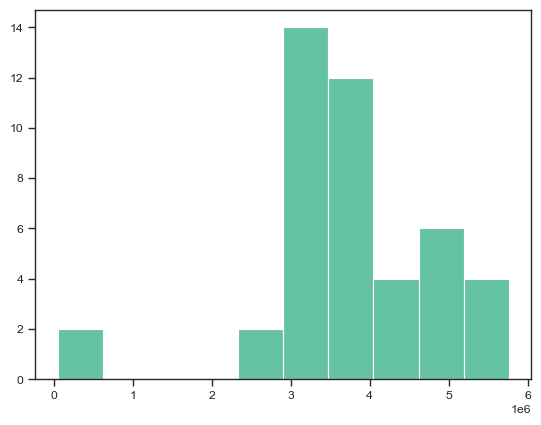

In [5]:
condition_columns = [i for i in reads_df.columns.tolist() if (i in tumor_samples)|(i in pre_injection_samples)]

#confirms that 1,000,000 threshold singles out low count samples
col_sums=reads_df[condition_columns].sum(axis=0)
col_sums.hist(grid=False)
plt.show()

In [6]:
#remove low count samples from condition columns 
condition_columns=col_sums[col_sums>1000000].index.tolist()

#drop spleen and low count samples
non_condition_cols=['sgRNA', 'Spacer', 'Gene']
keep_cols=[i for i in reads_df.columns if (i in condition_columns )| (i in non_condition_cols)]
reads_df=reads_df[keep_cols]
reads_df

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,...,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m9,GL261_m10,GL261_m11,Ctrl_c5,Ctrl_c6,Ctrl_c7
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,186,143,137
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,6,4,14715,0,3,0,0,...,0,0,0,0,0,0,0,34,29,41
2,1110032F04Rik_11,GTGGCGCTGGAGCCACCGAC,1110032F04Rik,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,3,1
3,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,134,115,135
4,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,19,21,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61906,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,0,0,0,0,0,0,0,...,22,1,0,1,0,0,0,48,35,40
61907,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,105,84,79
61908,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38,35,34
61909,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,19,11,22


Log-normalizing reads

In [7]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads

lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
lognorm_df

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,...,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m9,GL261_m10,GL261_m11,Ctrl_c5,Ctrl_c6,Ctrl_c7
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.649978,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,5.404380,5.184038,5.216883
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,1.496267,1.112341,11.891911,0.0,0.890421,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.097456,3.030278,3.564487
2,1110032F04Rik_11,GTGGCGCTGGAGCCACCGAC,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,0.530722,0.800488,0.338188
3,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.944469,4.879287,5.196241
4,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.385208,2.630366,2.311073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61906,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,3.079238,0.337443,0.0,0.36855,0.0,0.0,0.0,3.544936,3.270985,3.531908
61907,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.605508,4.444092,4.450834
61908,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.240068,3.270985,3.319288
61909,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.385208,1.895120,2.768014


Filtering out underrepresented sgRNAs

In [8]:
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA columns
z_scored_cols = []
for early in pre_injection_samples:
    z_col = early + '_z'
    filtered_lognorms[z_col] = (filtered_lognorms[early] - filtered_lognorms[early].mean())/filtered_lognorms[early].std()
    z_scored_cols.append(z_col)
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms[z_scored_cols].min(axis = 1) > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop(z_scored_cols, axis=1)
filtered_lognorms

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,...,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m9,GL261_m10,GL261_m11,Ctrl_c5,Ctrl_c6,Ctrl_c7
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.649978,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,5.404380,5.184038,5.216883
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,1.496267,1.112341,11.891911,0.0,0.890421,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.097456,3.030278,3.564487
2,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.944469,4.879287,5.196241
3,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.385208,2.630366,2.311073
4,1110032F04Rik_14,CAGTGAGTCCTGCGAGCCCG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.939185,3.539889,3.114513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60419,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,3.079238,0.337443,0.0,0.36855,0.0,0.0,0.0,3.544936,3.270985,3.531908
60420,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.605508,4.444092,4.450834
60421,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.240068,3.270985,3.319288
60422,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.385208,1.895120,2.768014


Calculate log fold change

Controls are not deliberately associated with any particular later time point samples, so the reference condition for all should be the average of the samples collected from NK cells pre-injection.

In [9]:
filtered_lognorms["NK_pre_injection"]=filtered_lognorms[pre_injection_samples].mean(axis=1)
filtered_lognorms=filtered_lognorms.drop(pre_injection_samples,axis=1)
condition_columns=[i for i in condition_columns if i not in pre_injection_samples]
filtered_lognorms

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,...,GL261_m2,GL261_m3,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m9,GL261_m10,GL261_m11,NK_pre_injection
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.649978,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,5.283303
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,1.496267,1.112341,11.891911,0.0,0.890421,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.384526
2,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.411615,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.963702
3,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.413747
4,1110032F04Rik_14,CAGTGAGTCCTGCGAGCCCG,1110032F04Rik,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.264242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60419,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,3.079238,0.337443,0.0,0.36855,0.0,0.0,0.0,3.516698
60420,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,4.321762
60421,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,3.153673
60422,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.0,2.399201


This dataset shows considerably sparsity, with the majority of guides within each sample having 0 counts. 


In [10]:
for cell_type in ["B16F10","E0771","Pano2","GL261"]:
    celltype_cols= [i for i in filtered_lognorms.columns if i.count(cell_type)>0]
    fraction_0_list=[]
    for col in celltype_cols:
        fraction_0_list.append(len(filtered_lognorms[filtered_lognorms[col]==0])/len(filtered_lognorms))
    print("Cell type: ", cell_type, "percent of sgRNAs with 0 counts", round(sum(fraction_0_list)/len(fraction_0_list),4)*100)

Cell type:  B16F10 percent of sgRNAs with 0 counts 83.35000000000001
Cell type:  E0771 percent of sgRNAs with 0 counts 81.31
Cell type:  Pano2 percent of sgRNAs with 0 counts 91.01
Cell type:  GL261 percent of sgRNAs with 0 counts 91.31


In [11]:
filtered_lognorms_ntc= filtered_lognorms[filtered_lognorms["Gene"]=="NTC"].reset_index(drop=True)
for cell_type in ["B16F10","E0771","Pano2","GL261"]:
    celltype_cols= [i for i in filtered_lognorms.columns if i.count(cell_type)>0]
    fraction_0_list=[]
    for col in celltype_cols:
        fraction_0_list.append(len(filtered_lognorms_ntc[filtered_lognorms_ntc[col]==0])/len(filtered_lognorms_ntc))
    print("Cell type: ", cell_type, "percent of sgRNAs with 0 counts", round(sum(fraction_0_list)/len(fraction_0_list),4)*100)

Cell type:  B16F10 percent of sgRNAs with 0 counts 83.42
Cell type:  E0771 percent of sgRNAs with 0 counts 80.92
Cell type:  Pano2 percent of sgRNAs with 0 counts 91.03999999999999
Cell type:  GL261 percent of sgRNAs with 0 counts 91.67999999999999


Calculating log fold change of gDNA lognorm counts in each mouse sample relative to average gDNA lognorm counts in pre-injection NK cells

In [12]:
lfc_df = filtered_lognorms.copy()

for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["NK_pre_injection"]
lfc_df=lfc_df.drop("NK_pre_injection",axis=1)
lfc_df

,sgRNA,Spacer,Gene,B16F10_m1,B16F10_m2,B16F10_m3,B16F10_m4,B16F10_m5,B16F10_m6,B16F10_m7,...,GL261_m1,GL261_m2,GL261_m3,GL261_m4,GL261_m5,GL261_m6,GL261_m7,GL261_m9,GL261_m10,GL261_m11
0,1110032F04Rik_1,CACGCCTTTCTGGACAACGT,1110032F04Rik,-5.283303,-5.283303,-5.283303,-5.283303,-4.633325,-5.283303,-5.283303,...,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303,-5.283303
1,1110032F04Rik_10,CCAGCTGCCCAGCTACGAGG,1110032F04Rik,-1.888259,-2.272184,8.507385,-3.384526,-2.494105,-3.384526,-3.384526,...,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526,-3.384526
2,1110032F04Rik_12,TTCGGAGCACGAGCTGCACG,1110032F04Rik,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,...,-4.545369,-4.552087,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702,-4.963702
3,1110032F04Rik_13,GCTGCAGCAGCTCAGCCCAG,1110032F04Rik,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,...,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747,-2.413747
4,1110032F04Rik_14,CAGTGAGTCCTGCGAGCCCG,1110032F04Rik,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,...,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242,-3.264242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60419,Zpld1_5,TAGCGATTAGAGTGAGTCCA,Zpld1,-3.516698,-3.516698,-3.516698,-3.516698,-3.516698,-3.516698,-3.516698,...,-3.098365,-3.516698,-3.516698,-0.437460,-3.179255,-3.516698,-3.148148,-3.516698,-3.516698,-3.516698
60420,Zpld1_6,ATTTCCAGAAGTGCTCTGCG,Zpld1,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,...,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762,-4.321762
60421,Zpld1_7,GACTCACTCTAATCGCTAGA,Zpld1,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,...,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673,-3.153673
60422,Zpld1_8,GATAGCTGATAACTGCTGGA,Zpld1,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,...,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201,-2.399201


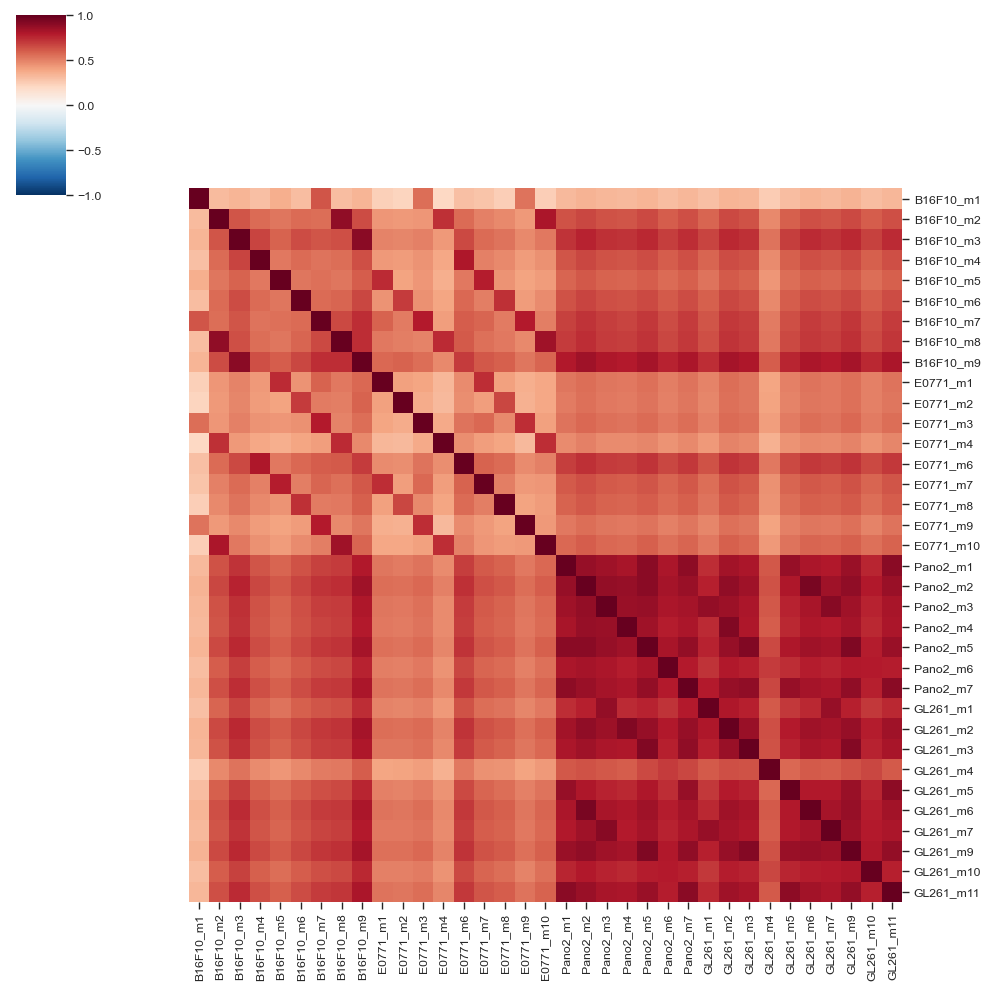

In [13]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=False,row_cluster=False,col_cluster=False)
plt.savefig("../Figures/replicate_correlation_peng2024nature.pdf")

Pan02 and GL261 mice have greater correlation with each other than other mice since they both received only 2 × 10^6 AAV–Surf-v2-infected NK cells. These samples appear to be well correlated across biological replicates (mice), but this is likely due to the fact that >91% of sgRNAs have 0 counts. By default, the log fold change is identical across replicates for guides that have 0 counts across tumor samples. 

B16F10 and E0771 mice received double the amount of NK cells, and as a result only have an average of ~81-83% of guides with 0 counts in final sample collection.  E0771 mice have the worst correlation with each other across replicates and have the smallest fraction of 0 gRNA counts across tumor types (81%).  B16F10 mice display slighty improved correlation, likely due to the fact that there are more 0s in their gRNA counts (83%). 


Identifying the guide-level log fold changes of hit genes identified in the manuscript with MAGeCK-RRA. Notably, the majority of guides targeting these genes feature similar phenotypes to the non-targeting controls.

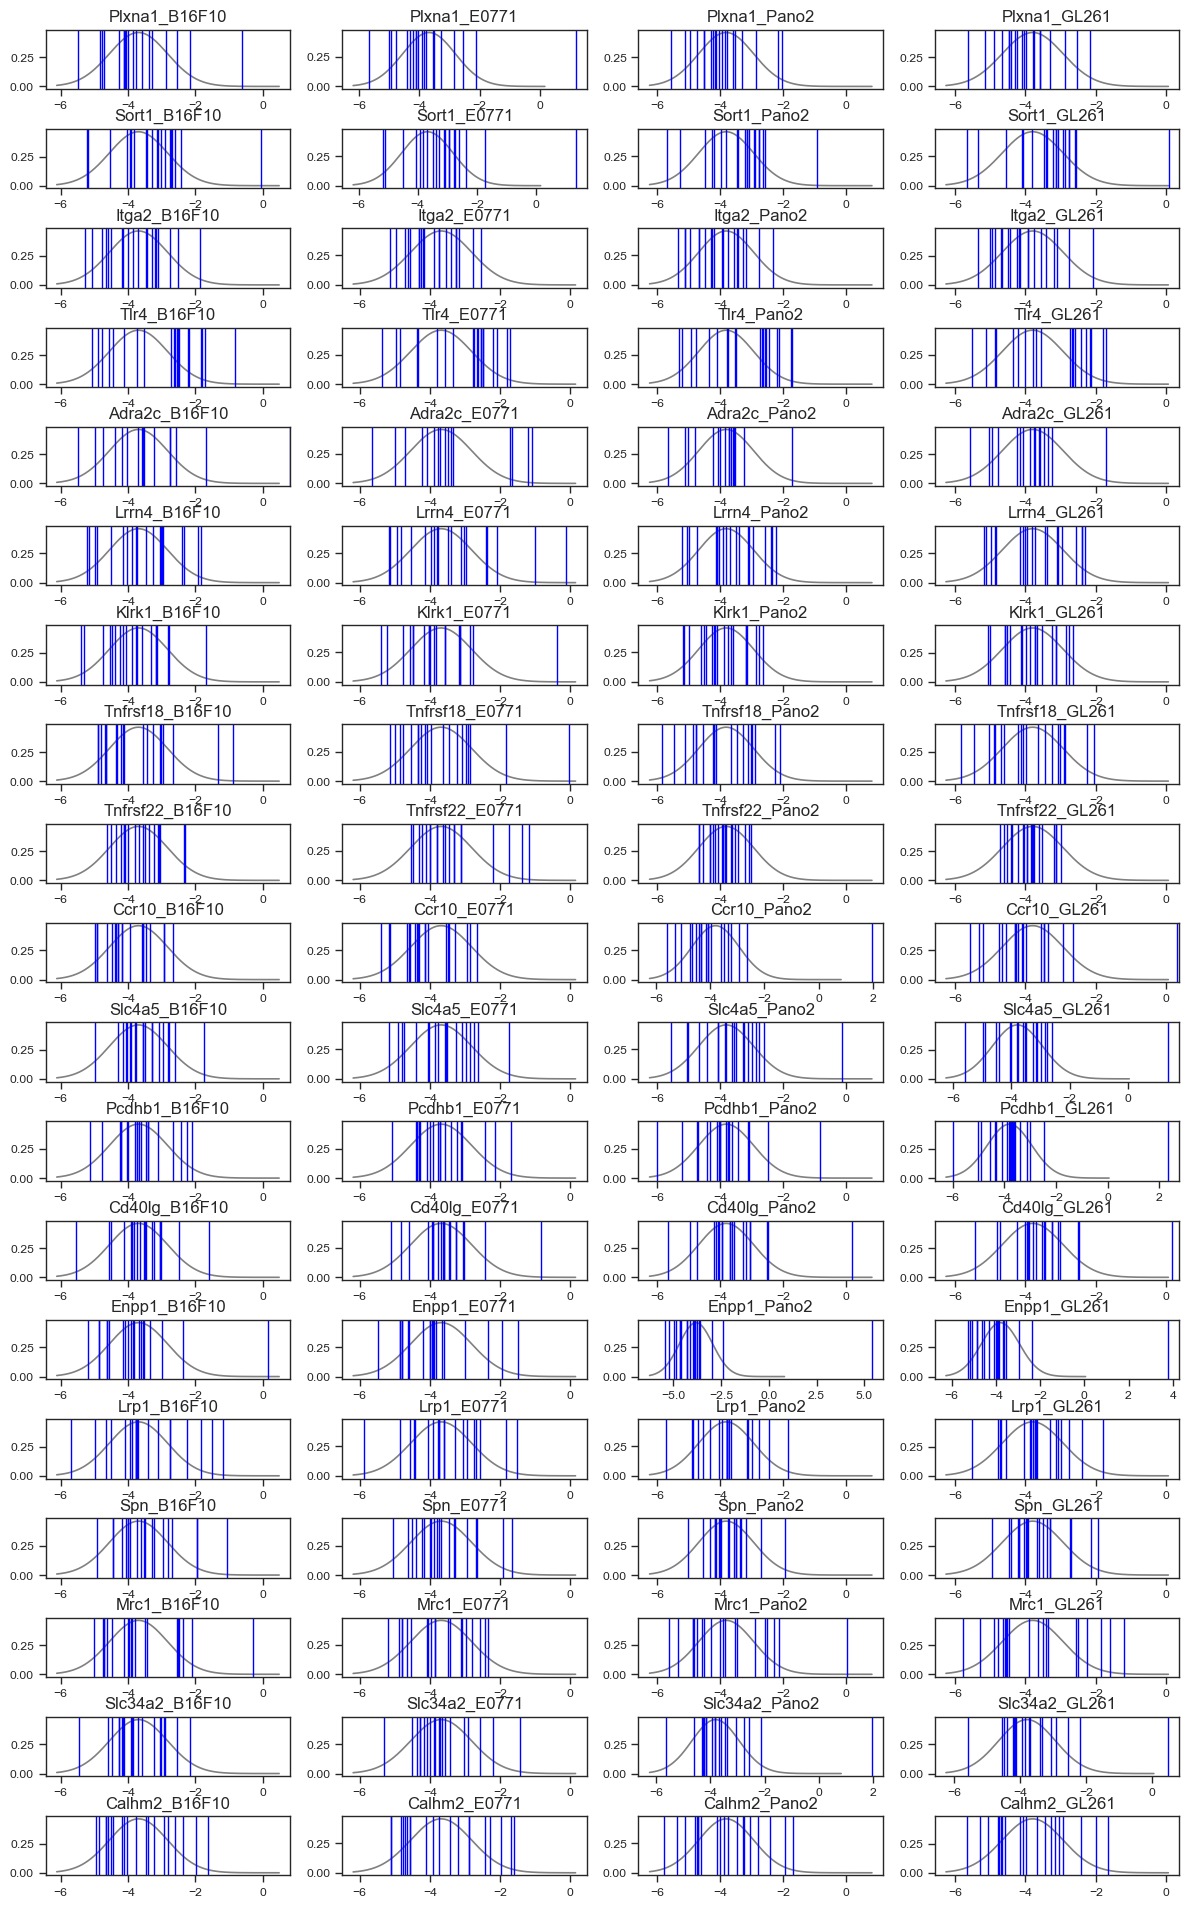

In [22]:
tumor_models=["B16F10","E0771","Pano2","GL261"]
B16F10_lfc_df=lfc_df[(i for i in lfc_df.columns if (i.count("B16F10")>0)|(i=="Gene"))]
E0771_lfc_df=lfc_df[(i for i in lfc_df.columns if (i.count("E0771")>0)|(i=="Gene"))]
Pano2_lfc_df=lfc_df[(i for i in lfc_df.columns if (i.count("Pano2")>0)|(i=="Gene"))]
GL261_lfc_df=lfc_df[(i for i in lfc_df.columns if (i.count("GL261")>0)|(i=="Gene"))]

tumor_model_dfs=[B16F10_lfc_df,E0771_lfc_df,Pano2_lfc_df,GL261_lfc_df]

#looking at hit genes from paper 
study_hit_genes=["Plxna1", "Sort1", "Itga2", "Tlr4", "Adra2c", "Lrrn4", "Klrk1", "Tnfrsf18", "Tnfrsf22", "Ccr10", "Slc4a5", "Pcdhb1", "Cd40lg", "Enpp1", "Lrp1", "Spn", "Mrc1", "Slc34a2", "Calhm2"]

(fig,ax)=plt.subplots(len(study_hit_genes),len(tumor_models),figsize=(12,len(study_hit_genes)))
fig.tight_layout()

for i in range(len(study_hit_genes)):
    focus_gene=study_hit_genes[i]
    for j in range(len(tumor_model_dfs)):
        tumor_model_df=tumor_model_dfs[j]
        #average gRNA counts across mice (biological replicates)
        tumor_model_df["avg_lfc"]=tumor_model_df.mean(axis=1,numeric_only=True)
        tumor_model=tumor_models[j]
        ax[i,j].set_title(focus_gene+"_"+tumor_model,fontsize=12)

        #background plot: NTC guides
        NTC_lfcs=tumor_model_df[(tumor_model_df["Gene"].str.contains("NTC"))]["avg_lfc"]
        NTC_lfcs_range=np.arange(NTC_lfcs.min(), NTC_lfcs.max(), 0.01) 
        ax[i,j].plot(NTC_lfcs_range, norm.pdf(NTC_lfcs_range,NTC_lfcs.mean(),NTC_lfcs.std()),color="grey") 

        #foreground: individual lfcs of guides targeting gene of interest
        focus_gene_lfcs=tumor_model_df[tumor_model_df["Gene"]==focus_gene]["avg_lfc"]
        for lfc in focus_gene_lfcs:
            ax[i,j].axvline(x=lfc,color="blue",linewidth=1)
gpp.savefig("../Figures/hit_genes_vs_NTC_peng2024nature_primaryscreen.pdf",dpi=600)

In [15]:
'''
(fig,ax)=plt.subplots(1,len(tumor_models),figsize=(12,2))
fig.suptitle("Calhm2-targeting guides in Peng et al Nature 2024")
fig.tight_layout()
for j in range(len(tumor_model_dfs)):
    tumor_model_df=tumor_model_dfs[j]
    #average gRNA counts across mice (biological replicates)
    tumor_model_df["avg_lfc"]=tumor_model_df.mean(axis=1,numeric_only=True)
    tumor_model=tumor_models[j]
    ax[j].set_title("tumor model: "+tumor_model)
    ax[j].set_xlabel("Log fold change")

    #background plot: NTC guides
    NTC_lfcs=tumor_model_df[(tumor_model_df["Gene"].str.contains("NTC"))]["avg_lfc"]
    NTC_lfcs_range=np.arange(NTC_lfcs.min(), NTC_lfcs.max(), 0.01) 
    ax[j].plot(NTC_lfcs_range, norm.pdf(NTC_lfcs_range,NTC_lfcs.mean(),NTC_lfcs.std()),color="grey") 

    #foreground: individual lfcs of guides targeting gene of interest
    calhm2_gene_lfcs=tumor_model_df[tumor_model_df["Gene"]=="Calhm2"]["avg_lfc"]
    for lfc in calhm2_gene_lfcs:
        ax[j].axvline(x=lfc,color="blue",linewidth=1)
plt.savefig("../Figures/calhm2_vs_NTC_peng2024nature_primaryscreen.pdf",bbox_inches="tight")
'''

'\n(fig,ax)=plt.subplots(1,len(tumor_models),figsize=(12,2))\nfig.suptitle("Calhm2-targeting guides in Peng et al Nature 2024")\nfig.tight_layout()\nfor j in range(len(tumor_model_dfs)):\n    tumor_model_df=tumor_model_dfs[j]\n    #average gRNA counts across mice (biological replicates)\n    tumor_model_df["avg_lfc"]=tumor_model_df.mean(axis=1,numeric_only=True)\n    tumor_model=tumor_models[j]\n    ax[j].set_title("tumor model: "+tumor_model)\n    ax[j].set_xlabel("Log fold change")\n\n    #background plot: NTC guides\n    NTC_lfcs=tumor_model_df[(tumor_model_df["Gene"].str.contains("NTC"))]["avg_lfc"]\n    NTC_lfcs_range=np.arange(NTC_lfcs.min(), NTC_lfcs.max(), 0.01) \n    ax[j].plot(NTC_lfcs_range, norm.pdf(NTC_lfcs_range,NTC_lfcs.mean(),NTC_lfcs.std()),color="grey") \n\n    #foreground: individual lfcs of guides targeting gene of interest\n    calhm2_gene_lfcs=tumor_model_df[tumor_model_df["Gene"]=="Calhm2"]["avg_lfc"]\n    for lfc in calhm2_gene_lfcs:\n        ax[j].axvline(x=lfc

Identifying the direct results of MAGeCK used to call hits in this study (Downloaded from Supplementary Data 1)

In [16]:
mageck_results_B16F10= pd.read_table("../Data/PengNature2024/mageck_B16F10_results.txt.gene_summary.txt")
mageck_results_E0771= pd.read_table("../Data/PengNature2024/mageck_E0771_results.txt.gene_summary.txt")
mageck_results_GL261= pd.read_table("../Data/PengNature2024/mageck_GL261_results.txt.gene_summary.txt")
mageck_results_Pano2= pd.read_table("../Data/PengNature2024/mageck_Pano2_results.txt.gene_summary.txt")

all_mageck_results=pd.concat([mageck_results_B16F10,mageck_results_E0771,mageck_results_GL261,mageck_results_Pano2],keys=["B16F10","E0771","GL261","Pano2"]).reset_index()
all_mageck_results=all_mageck_results.rename(columns={"level_0":"tumor model","id":"Gene"})
all_mageck_results=all_mageck_results[["tumor model","Gene","pos|goodsgrna"]]
mageck_results_studyhits=all_mageck_results[all_mageck_results["Gene"].isin(study_hit_genes)]

mageck_results_studyhits[mageck_results_studyhits["pos|goodsgrna"]>0]

,tumor model,Gene,pos|goodsgrna
4212,E0771,Plxna1,1
6297,GL261,Enpp1,1
6392,GL261,Pcdhb1,1
7573,GL261,Cd40lg,1
9158,Pano2,Enpp1,1
10237,Pano2,Slc34a2,1


Notably, for the main screen hit Calhm2, MAGeCK only uses 60% of the guides targeting this gene to determine that it is a hit. The algorithm determined that the remaining 40% reflected low guide efficiency, and thus their screening behavior had no influence on whether or not MAGeCK called Calhm2 a hit. 

In [17]:
mageck_results_studyhits[mageck_results_studyhits["Gene"]=="Calhm2"]

,tumor model,Gene,pos|goodsgrna
541,B16F10,Calhm2,0
3391,E0771,Calhm2,0
6268,GL261,Calhm2,0
9138,Pano2,Calhm2,0


To identify the impact of the choice of hit-calling method (MAGeCK RRA) in this study, I am identifying if these genes emerge as a hit with the Z-score method. 

In [18]:
all_lfcs=pd.concat([B16F10_lfc_df,E0771_lfc_df,GL261_lfc_df,Pano2_lfc_df],keys=["B16F10","E0771","GL261","Pano2"]).reset_index().rename(columns={"level_0":"tumor model"})[["tumor model","Gene","avg_lfc"]]

control_sgrna_lfcs = all_lfcs[(all_lfcs['Gene'].str.count("NTC")>0)].reset_index(drop=True)
control_sgrna_stats = (control_sgrna_lfcs.groupby('tumor model')
                       .agg(neg_ctl_mean = ('avg_lfc', 'mean'),
                            neg_ctl_sd = ('avg_lfc', 'std'))
                       .reset_index())

zscored_sgrna_lfcs = all_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='tumor model'))
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs['avg_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean','avg_lfc'], axis=1)

zscored_gene_lfcs = (zscored_sgrna_lfcs.groupby(['Gene', 'tumor model'])
                     .agg(z_scored_lfc_sum = ('z_scored_sgRNA_lfc', 'sum'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())
zscored_gene_lfcs['gene_zscore'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas']))
zscored_gene_lfcs = zscored_gene_lfcs.drop('z_scored_lfc_sum', axis=1)
zscored_gene_lfcs

,Gene,tumor model,n_sgrnas,gene_zscore
0,1110032F04Rik,B16F10,19,1.031022
1,1110032F04Rik,E0771,19,0.544487
2,1110032F04Rik,GL261,19,0.426425
3,1110032F04Rik,Pano2,19,0.355815
4,1700017D01Rik,B16F10,20,-0.529673
...,...,...,...,...
11435,Zp3,Pano2,20,-1.061543
11436,Zpld1,B16F10,20,1.217875
11437,Zpld1,E0771,20,0.999539
11438,Zpld1,GL261,20,1.441746


In [19]:
#randomly sample controls to create pseudogenes, calculate aggregate z-score for each pseudogene
def get_pseudogene_distribution(df_with_guide_zscores,df_with_gene_zscores):
    #get guide-level z-scores of controls
    control_zscores= df_with_guide_zscores[df_with_guide_zscores["Gene"].str.count("NTC")>0].reset_index(drop=True)

    #num guides in each pseudogene is average num guides per gene in screen 
    num_guides_per_pseudogene= round(df_with_gene_zscores["n_sgrnas"].mean())
    
    random.seed(0)
    num_pseudogenes=1000
    control_pseudogene_zscores=[]
    for i in range(num_pseudogenes):
        #select n random indices from the list of control guides (n being the number of guides in a pseudogene)
        #sampling with replacement enables a more representative distribution, beneficial for small control set size
        control_guides_in_pseudogene=random.choices(range(len(control_zscores)), k=num_guides_per_pseudogene)
        control_pseudogene= control_zscores.loc[control_guides_in_pseudogene,:]
        #implements stouffers to calculate pseudogene-level z-score from z-score of each guide in pseudogene 
        control_pseudogene_zscores.append( control_pseudogene["z_scored_sgRNA_lfc"].sum()/np.sqrt(num_guides_per_pseudogene))
    control_pseudogene_zscores.sort()
    return control_pseudogene_zscores

#calculate control pseudogene distribution separately for each condition
control_pseudogene_zscore_distribution_map={}
for tumor_model in zscored_gene_lfcs["tumor model"].unique():
    control_pseudogene_zscore_distribution_map[tumor_model]= get_pseudogene_distribution(zscored_sgrna_lfcs[zscored_sgrna_lfcs["tumor model"]==tumor_model].reset_index(),zscored_gene_lfcs[zscored_gene_lfcs["tumor model"]==tumor_model].reset_index())

def get_empirical_gene_pval(gene_level_z_score,condition):
    #use the control distribution that corresponds to the condition that the gene-level z-score is calculated from
    control_pseudogene_zscores= control_pseudogene_zscore_distribution_map[condition]
    #estimate probability distribution of pseudogene z-scores to get AUC for pval
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    ha_greater=kde.integrate_box_1d(gene_level_z_score, np.inf)
    strongest_p_val=np.min([ha_less,ha_greater])
    return strongest_p_val

zscored_gene_lfcs['empirical_pvalue'] = zscored_gene_lfcs.apply(lambda x: get_empirical_gene_pval(x.gene_zscore,x["tumor model"]),axis=1)

#obtaining False Discovery Rate with Benjamini-Hochberg multiple testing correction 
zscored_gene_lfcs=zscored_gene_lfcs.sort_values(by="tumor model")
zscored_gene_lfcs_agg_by_condition=zscored_gene_lfcs.groupby("tumor model").agg(list).reset_index()
zscored_gene_lfcs_agg_by_condition["FDR"]=zscored_gene_lfcs_agg_by_condition["empirical_pvalue"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
zscored_gene_lfcs["FDR"]= zscored_gene_lfcs_agg_by_condition["FDR"].explode().tolist()

zscored_gene_lfcs

,Gene,tumor model,n_sgrnas,gene_zscore,empirical_pvalue,FDR
0,1110032F04Rik,B16F10,19,1.031022,0.160114,0.445533
8180,Pi16,B16F10,20,-1.063763,0.140174,0.442492
2428,Fam171a1,B16F10,18,-1.233732,0.104447,0.417007
4972,Mfsd12,B16F10,20,-0.505384,0.319805,0.471222
9648,Slc36a3,B16F10,20,-1.135337,0.124039,0.434562
...,...,...,...,...,...,...
6095,Olfr1293-ps,Pano2,20,0.578727,0.283745,0.480483
6091,Olfr1291-ps1,Pano2,20,0.601511,0.276103,0.479327
6087,Olfr1289,Pano2,20,-0.034776,0.499398,0.499898
6111,Olfr1310,Pano2,20,1.579856,0.059089,0.365048


In [20]:
print("total # genes that emerge as a hit with Z-score method:",len(zscored_gene_lfcs[zscored_gene_lfcs["FDR"]<0.05]["Gene"].unique()))
print("# genes that hit with MAGeCK RRA (reported in study) that emerge as a hit with Z-score method:",len(zscored_gene_lfcs[(zscored_gene_lfcs["FDR"]<0.05)&(zscored_gene_lfcs["Gene"].isin(study_hit_genes))]))


total # genes that emerge as a hit with Z-score method: 37
# genes that hit with MAGeCK RRA (reported in study) that emerge as a hit with Z-score method: 0
